<a href="https://colab.research.google.com/github/veerakumar17/veera-codeboosters-2026/blob/main/day3/day3miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
API_KEY = '34bf3577badd62038def839c765915e6'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur'
]

print(f'API configured for {len(CITIES)} cities')
print(f'BASE_URL = {BASE_URL}')
print(f'CITIES = {CITIES}')

API configured for 7 cities
BASE_URL = https://api.openweathermap.org/data/2.5/weather
CITIES = ['Mumbai', 'Bangalore', 'Chennai', 'Hyderabad', 'Kolkata', 'Pune', 'Jaipur']


In [9]:
import requests

API_KEY = 'f93e5d4a1dc43dd0f13a34d059136b16'

BASE_URL = 'https://api.openweathermap.org/data/2.5/weather'

CITIES = [
    'Mumbai',
    'Bangalore',
    'Chennai',
    'Hyderabad',
    'Kolkata',
    'Pune',
    'Jaipur',
    'Coimbatore'
]


# Function to fetch weather data
def fetch_weather(city, API_KEY):
    """
    Fetch current weather data for a given city.
    Returns weather details dictionary or None on failure.
    """
    params = {
        'q': city,
        'appid': API_KEY,
        'units': 'metric'
    }

    try:
        response = requests.get(BASE_URL, params=params, timeout=10)

        if response.status_code == 200:
            data = response.json()
            return {
                'city': data['name'],
                'temperature': data['main']['temp'],
                'description': data['weather'][0]['description'],
                'icon': data['weather'][0]['icon'],
                'humidity': data['main']['humidity'],
                'wind_speed': data['wind']['speed'],
                'pressure': data['main']['pressure'],
                'visibility': data.get('visibility', 0),
                'sunrise': data['sys']['sunrise'],
                'sunset': data['sys']['sunset']
            }
        else:
            print(f"Error fetching weather data for {city}")
            print(f"Status code: {response.status_code}")
            return None

    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        return None


# Call API for all cities
print("Calling Weather API...\n")

weather_records = []

for city in CITIES:
    print(f"Fetching weather for {city}...", end=' ')
    record = fetch_weather(city, API_KEY)
    if record:
        weather_records.append(record)
        print(
            f"{record['temperature']}°C, "
            f"{record['description']}"
        )
    else:
        print("Failed")

print("\nWeather Records:\n")
for record in weather_records:
    print(record)

Calling Weather API...

Fetching weather for Mumbai... 31.99°C, haze
Fetching weather for Bangalore... 26.55°C, scattered clouds
Fetching weather for Chennai... 32.2°C, haze
Fetching weather for Hyderabad... 31.23°C, broken clouds
Fetching weather for Kolkata... 31.97°C, haze
Fetching weather for Pune... 29.91°C, clear sky
Fetching weather for Jaipur... 31.62°C, haze
Fetching weather for Coimbatore... 28.88°C, few clouds

Weather Records:

{'city': 'Mumbai', 'temperature': 31.99, 'description': 'haze', 'icon': '50d', 'humidity': 62, 'wind_speed': 5.14, 'pressure': 1011, 'visibility': 5000, 'sunrise': 1780014660, 'sunset': 1780062077}
{'city': 'Bengaluru', 'temperature': 26.55, 'description': 'scattered clouds', 'icon': '03d', 'humidity': 75, 'wind_speed': 8.94, 'pressure': 1014, 'visibility': 6000, 'sunrise': 1780014151, 'sunset': 1780060303}
{'city': 'Chennai', 'temperature': 32.2, 'description': 'haze', 'icon': '50d', 'humidity': 64, 'wind_speed': 4.12, 'pressure': 1006, 'visibility'

In [10]:
import pandas as pd
weather_df=pd.DataFrame(weather_records)
print('Weather DataFrame created:')
print(weather_df.to_string(index=False))
print(weather_df.shape)
print(f'Missing Values:',{weather_df.isnull().sum().sum()})
print(f'\nData types:')
print(weather_df.dtypes)

Weather DataFrame created:
      city  temperature      description icon  humidity  wind_speed  pressure  visibility    sunrise     sunset
    Mumbai        31.99             haze  50d        62        5.14      1011        5000 1780014660 1780062077
 Bengaluru        26.55 scattered clouds  03d        75        8.94      1014        6000 1780014151 1780060303
   Chennai        32.20             haze  50d        64        4.12      1006        4000 1780013498 1780059672
 Hyderabad        31.23    broken clouds  04d        55        8.23      1011        6000 1780013486 1780060550
   Kolkata        31.97             haze  50d        70        3.60      1007        2800 1780010538 1780058748
      Pune        29.91        clear sky  01d        50        5.58      1012       10000 1780014472 1780061782
    Jaipur        31.62             haze  50d        33        4.63      1005        3000 1780013031 1780062281
Coimbatore        28.88       few clouds  02d        65        3.09      1013

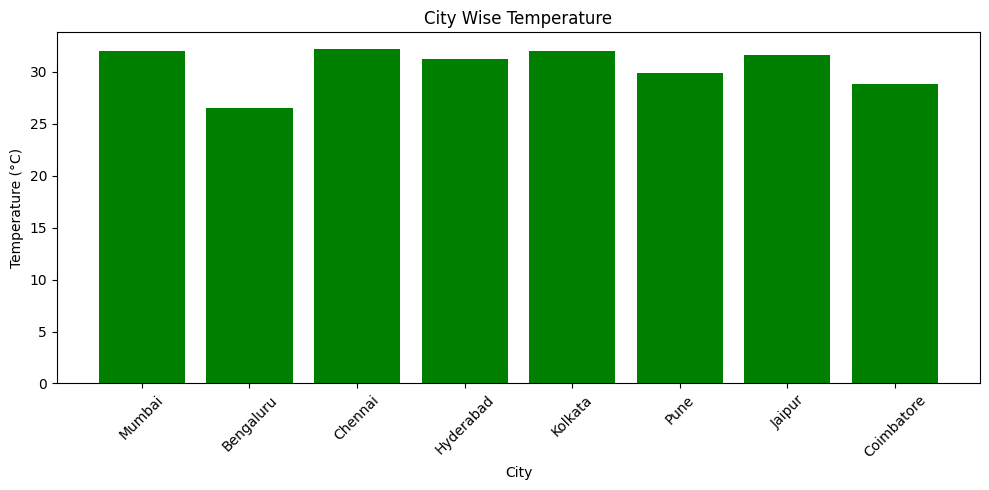

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))

plt.bar(
    weather_df['city'],
    weather_df['temperature'],
    color='green'
)

plt.title('City Wise Temperature')

plt.xlabel('City')

plt.ylabel('Temperature (°C)')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()